In [1]:
import glob
import os
import time

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import librosa
import librosa.display

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_curve,
    auc,
    precision_recall_curve,
    ConfusionMatrixDisplay
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC

from tqdm.notebook import tqdm

# Consts and Functions

In [2]:
DIR_BASE = '/Users/calvinhinkle/Desktop/school/mines/2026/spring/adML/finalProj/'
DIR_DRONE = os.path.join(DIR_BASE, 'Binary_Drone_Audio/yes_drone')
DIR_UNKNOWN = os.path.join(DIR_BASE, 'Binary_Drone_Audio/unknown')
DIR_TEST = os.path.join(DIR_BASE, 'live_samples')

DURATION = 1.024  #sec
SR = 16000

LENGTH_N = int(SR * DURATION)

N_FFT = 1024
HOP_LENGTH = N_FFT // 4

TEST_FRAC = 0.2
RANDOM_SEED = 42

In [3]:
#audio processing
def fix_length(y, target_len):
    if len(y) > target_len:
        return y[:target_len]
    else:
        return np.pad(y, (0, target_len - len(y)))

def preprocess(path):
    y_raw, _ = librosa.load(path, mono=True, sr=SR) #NEED sr=SR

    # normalize amplitude
    y_norm = librosa.util.normalize(y_raw)

    # force fixed duration
    y = fix_length(y_norm, LENGTH_N)

    return y

In [4]:
#feature extraction

def extract_features(y, sr=SR):

    features = []

    S = np.abs(librosa.stft(y, n_fft=N_FFT, hop_length=HOP_LENGTH))

    #mfcc
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=20)

    features.extend(np.mean(mfcc, axis=1))
    features.extend(np.std(mfcc, axis=1))
    
    #time mfcc data
    delta_mfcc = librosa.feature.delta(mfcc)
    delta2_mfcc = librosa.feature.delta(mfcc, order=2)

    features.extend(np.mean(delta_mfcc, axis=1))
    features.extend(np.std(delta_mfcc, axis=1))

    features.extend(np.mean(delta2_mfcc, axis=1))
    features.extend(np.std(delta2_mfcc, axis=1))

    #spectral feats
    spec_centroid = librosa.feature.spectral_centroid(S=S, sr=sr)
    spec_bandwidth = librosa.feature.spectral_bandwidth(S=S, sr=sr)
    spec_rolloff = librosa.feature.spectral_rolloff(S=S, sr=sr)
    spec_contrast = librosa.feature.spectral_contrast(S=S, sr=sr)

    for f in [spec_centroid, spec_bandwidth, spec_rolloff]:
        features.append(np.mean(f))
        features.append(np.std(f))

    features.extend(np.mean(spec_contrast, axis=1))
    features.extend(np.std(spec_contrast, axis=1))

    #harmonic, percussive
    y_harm, y_perc = librosa.effects.hpss(y)
    features.append(np.sum(y_harm ** 2))
    #features.append(np.sum(y_perc ** 2))

    #zero crossing rate
    zcr = librosa.feature.zero_crossing_rate(y)
    features.append(np.mean(zcr))
    features.append(np.std(zcr))

    return np.array(features, dtype=np.float32)

In [5]:
#.wav to features
def wav_to_data(filepath):

    data = preprocess(filepath)

    if data.ndim > 1:
        data = data.mean(axis=1)

    features = extract_features(data)

    return features

def load_dataset(dir_drone, dir_unknown):
    X = []
    y = []

    # 0 = drone
    # 1 = unknown
    for label, folder in [(0, dir_drone), (1, dir_unknown)]:
        for filename in tqdm(sorted(os.listdir(folder)):
            if not filename.lower().endswith(".wav"):
                continue
            filepath = os.path.join(folder, filename)
            try:
                features = wav_to_data(filepath)
                X.append(features)
                y.append(label)
            except Exception as e:
                print(f"Skipping {filepath}: {e}")
    X = np.stack(X)
    y = np.array(y, dtype=np.int64)
    return X, y

# Load data

In [6]:
start = time.perf_counter()
X, y = load_dataset(
    dir_drone=DIR_DRONE,
    dir_unknown=DIR_UNKNOWN
)
end = time.perf_counter()
loadTime = end-start

In [7]:
print(f'time taken: {loadTime:.4f} sec = {loadTime/60:.2f} min')
print(f'Dataset (X) shape: {X.shape}')
print(f'Labels (y) shape: {y.shape}')

time taken: 413.6839 sec = 6.89 min
Dataset (X) shape: (11704, 143)
Labels (y) shape: (11704,)


In [8]:
start = time.perf_counter()
X_train, X_test, y_train, y_test = train_test_split(X, y,
    test_size=TEST_FRAC, random_state=RANDOM_SEED, stratify=y)
end = time.perf_counter()
ttslpitTime = end-start

In [9]:
print(f'time taken: {ttslpitTime:.4f} s = {ttslpitTime*1e3:.1f} ms')

time taken: 0.0081 s = 8.1 ms


# Logisitic Regression

In [10]:
log_model = Pipeline([("scaler", StandardScaler()),
                  
                  ("classifier", LogisticRegression(
                      max_iter=5000, 
                      class_weight="balanced",
                      random_state=RANDOM_SEED) 
                  )])

## Train

In [11]:
start = time.perf_counter()
log_model.fit(X_train, y_train)
end = time.perf_counter()
logTrainTime = end-start

In [12]:
print(f'time taken: {logTrainTime:.4f} s = {logTrainTime*1e3:.1f} ms')

time taken: 0.2223 s = 222.3 ms


## Predict

In [13]:
start = time.perf_counter()
y_pred_log = log_model.predict(X_test)

y_probs_log = log_model.predict_proba(X_test)[:, 0]

#find good level for this
threshold = 0.75 #need to be 75% sure it is a drone

# class 0 = drone
y_pred_log_thresh = np.where(y_probs_log > threshold, 0, 1)
end = time.perf_counter()
logPredictTime = end-start

In [14]:
print(f'time taken: {logPredictTime:.4f} s = {logPredictTime*1e3:.1f} ms')

time taken: 0.0055 s = 5.5 ms


## Metrics

In [15]:
drone_true = (y_test == 0).astype(int)

metrics = {
    "accuracy": accuracy_score(y_test, y_pred_log_thresh),

    "balanced_accuracy": balanced_accuracy_score(y_test, y_pred_log_thresh),

    "drone_precision": precision_score(y_test, y_pred_log_thresh, pos_label=0, 
                                       zero_division=0),

    "drone_recall": recall_score(y_test, y_pred_log_thresh, pos_label=0,
                                 zero_division=0),

    "drone_f1": f1_score(y_test, y_pred_log_thresh, pos_label=0, zero_division=0),

    "drone_pr_auc": average_precision_score(drone_true, y_pred_log_thresh),

    "confusion_matrix": confusion_matrix(y_test, y_pred_log_thresh, labels=[0, 1])
    }

In [16]:
print("\nmetrics")

for key, value in metrics.items():

    if key == "confusion_matrix":
        continue

    print(f"{key}: {value:.4f}")

print("\nConfusion Matrix:")
print(metrics["confusion_matrix"])

print("\nClassification Report:")
print(classification_report(y_test, y_pred_log_thresh))


metrics
accuracy: 0.9714
balanced_accuracy: 0.9396
drone_precision: 0.8566
drone_recall: 0.8985
drone_f1: 0.8771
drone_pr_auc: 0.1034

Confusion Matrix:
[[ 239   27]
 [  40 2035]]

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.90      0.88       266
           1       0.99      0.98      0.98      2075

    accuracy                           0.97      2341
   macro avg       0.92      0.94      0.93      2341
weighted avg       0.97      0.97      0.97      2341



## Figures

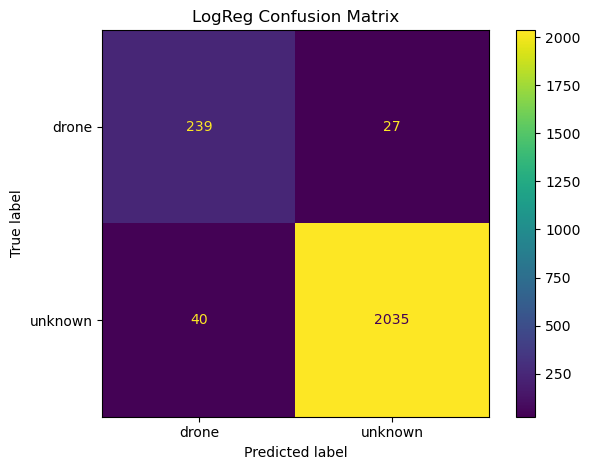

Num features: 143
Num coeffs:   143


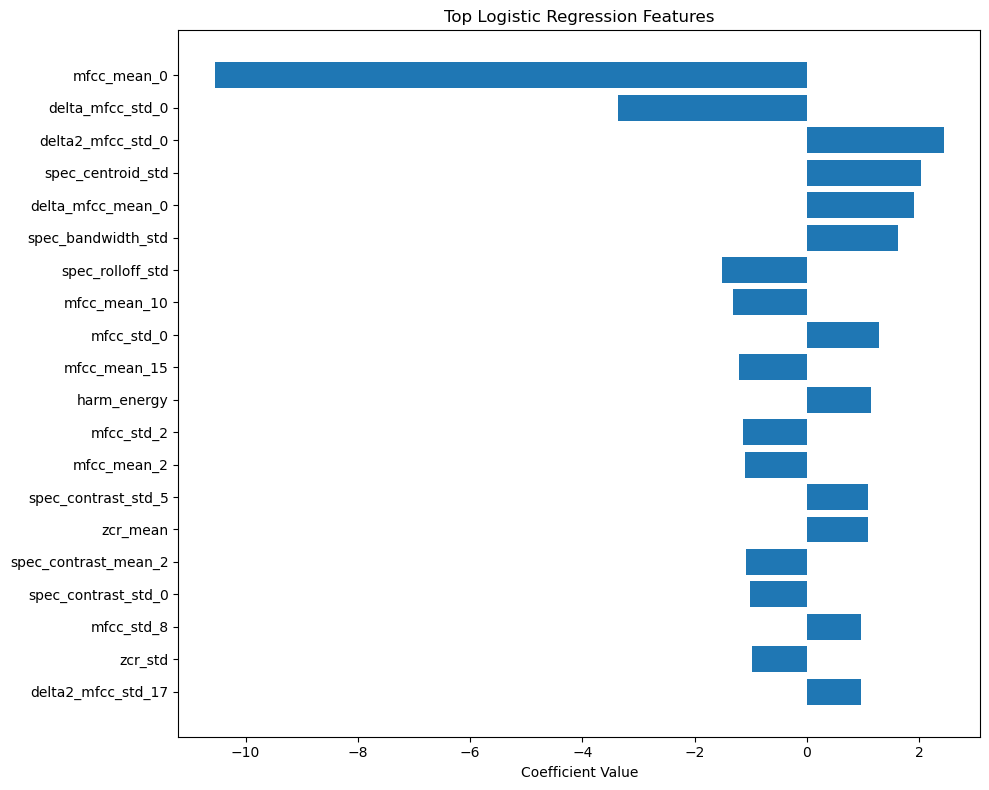

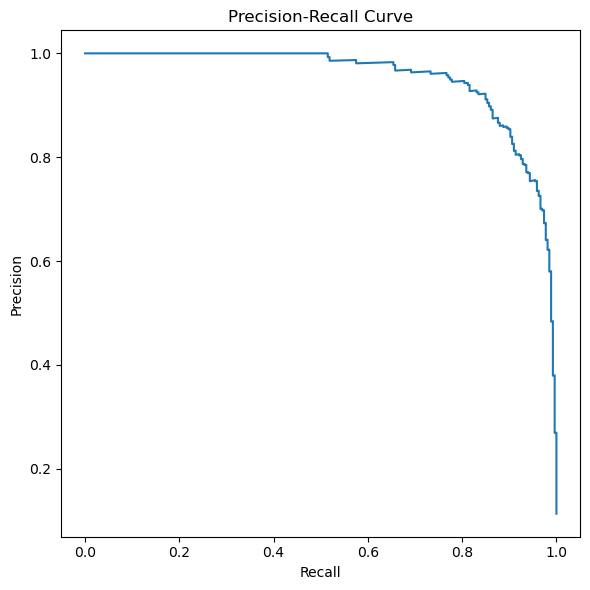

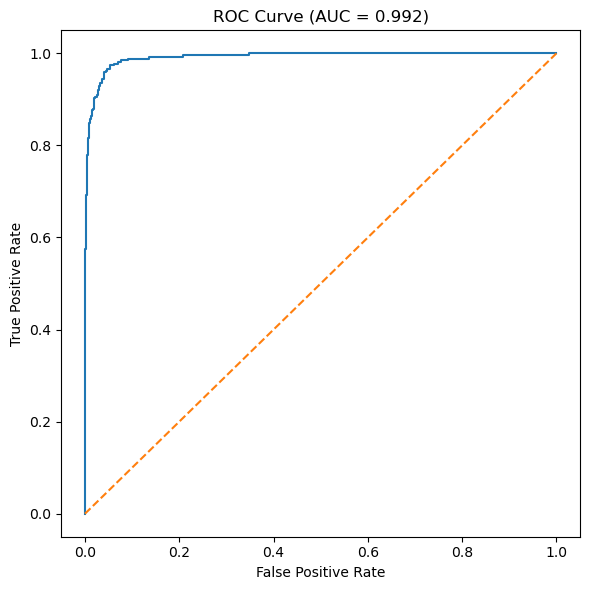

ROC AUC: 0.9917


In [17]:
#confusion matrix
cm = metrics["confusion_matrix"]
im = ConfusionMatrixDisplay(confusion_matrix=cm, 
                            display_labels=["drone", "unknown"])
im.plot()
plt.title("LogReg Confusion Matrix")
plt.tight_layout()
plt.show()


#most impactful features
classifier = log_model.named_steps["classifier"]
coeffs = classifier.coef_[0]

feature_names = []

for i in range(20):
    feature_names.append(f"mfcc_mean_{i}")

for i in range(20):
    feature_names.append(f"mfcc_std_{i}")

for i in range(20):
    feature_names.append(f"delta_mfcc_mean_{i}")

for i in range(20):
    feature_names.append(f"delta_mfcc_std_{i}")

for i in range(20):
    feature_names.append(f"delta2_mfcc_mean_{i}")

for i in range(20):
    feature_names.append(f"delta2_mfcc_std_{i}")

feature_names += [
    "spec_centroid_mean",
    "spec_centroid_std",
    "spec_bandwidth_mean",
    "spec_bandwidth_std",
    "spec_rolloff_mean",
    "spec_rolloff_std",
]

for i in range(7):
    feature_names.append(f"spec_contrast_mean_{i}")

for i in range(7):
    feature_names.append(f"spec_contrast_std_{i}")

feature_names += ["harm_energy"]

feature_names += ["zcr_mean", "zcr_std"]

print("Num features:", len(feature_names))
print("Num coeffs:  ", len(coeffs))

importance = np.abs(coeffs)
top_n = 20
top_idx = np.argsort(importance)[-top_n:]
top_features = [feature_names[i] for i in top_idx]
top_values = coeffs[top_idx]
fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(top_features, top_values)
ax.set_title("Top Logistic Regression Features")
ax.set_xlabel("Coefficient Value")
plt.tight_layout()
plt.show()

#pr curve
drone_probs = log_model.predict_proba(X_test)[:, 0]
drone_true = (y_test == 0).astype(int)
precision, recall, _ = precision_recall_curve(
    drone_true, drone_probs)
fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(recall, precision)
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curve")
plt.tight_layout()
plt.show()

#roc curve
fpr, tpr, _ = roc_curve(drone_true, drone_probs)
roc_auc_logReg = auc(fpr, tpr)
fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(fpr, tpr)
ax.plot([0, 1], [0, 1], linestyle="--")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title(f"ROC Curve (AUC = {roc_auc_logReg:.3f})")
plt.tight_layout()
plt.show()
plt.close()

print(f'ROC AUC: {roc_auc_logReg:.4f}')

# SVM

In [18]:
svm_model = Pipeline([
    ("scaler", StandardScaler()),

    ("classifier", LinearSVC(
        C=35, #found optimal value in other notebook
        class_weight="balanced",
        max_iter=50000,
        dual=False,
        random_state=RANDOM_SEED) )
])

## Train

In [19]:
start = time.perf_counter()
svm_model.fit(X_train, y_train)
end = time.perf_counter()
svmTrainTime = end-start

In [20]:
print(f'time taken: {svmTrainTime:.2f} s = {svmTrainTime*1e3:.1f} ms')

time taken: 0.16 s = 158.5 ms


## Predict

In [21]:
start = time.perf_counter()
#hard
#y_pred = svm_model.predict(X_test)

#soft
scores = svm_model.decision_function(X_test)

# drone = class 0
drone_scores = -scores

threshold = 0.513 #found in other nb
#threshold = 0.6

y_pred_svm = np.where(drone_scores > threshold, 0, 1)

drone_true = (y_test == 0).astype(int)
end = time.perf_counter()
svmPredictTime = end-start

In [22]:
print(f'time taken: {svmPredictTime:.4f} s = {svmPredictTime*1e3:.1f} ms')

time taken: 0.0019 s = 1.9 ms


## Metrics

In [23]:
svm_metrics = {
    "accuracy": accuracy_score(y_test, y_pred_svm),

    "balanced_accuracy": balanced_accuracy_score(y_test, y_pred_svm),

    "drone_precision": precision_score(y_test, y_pred_svm, pos_label=0, zero_division=0),

    "drone_recall": recall_score(y_test, y_pred_svm, pos_label=0, zero_division=0),

    "drone_f1": f1_score(y_test, y_pred_svm, pos_label=0, zero_division=0),

    "drone_pr_auc": average_precision_score(drone_true, drone_scores),

    "confusion_matrix": confusion_matrix(y_test, y_pred_svm, labels=[0, 1])
}

In [24]:
print("\nmetrics")

for key, value in svm_metrics.items():

    if key == "confusion_matrix":
        continue

    print(f"{key}: {value:.4f}")

print("\nConfusion Matrix:")
print(svm_metrics["confusion_matrix"])

print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm))


metrics
accuracy: 0.9705
balanced_accuracy: 0.9277
drone_precision: 0.8689
drone_recall: 0.8722
drone_f1: 0.8705
drone_pr_auc: 0.9513

Confusion Matrix:
[[ 232   34]
 [  35 2040]]

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.87      0.87       266
           1       0.98      0.98      0.98      2075

    accuracy                           0.97      2341
   macro avg       0.93      0.93      0.93      2341
weighted avg       0.97      0.97      0.97      2341



## Figures

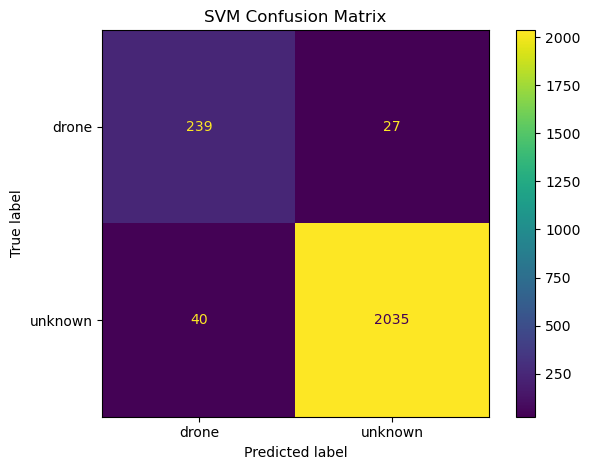

Num features: 143
Num coeffs:   143


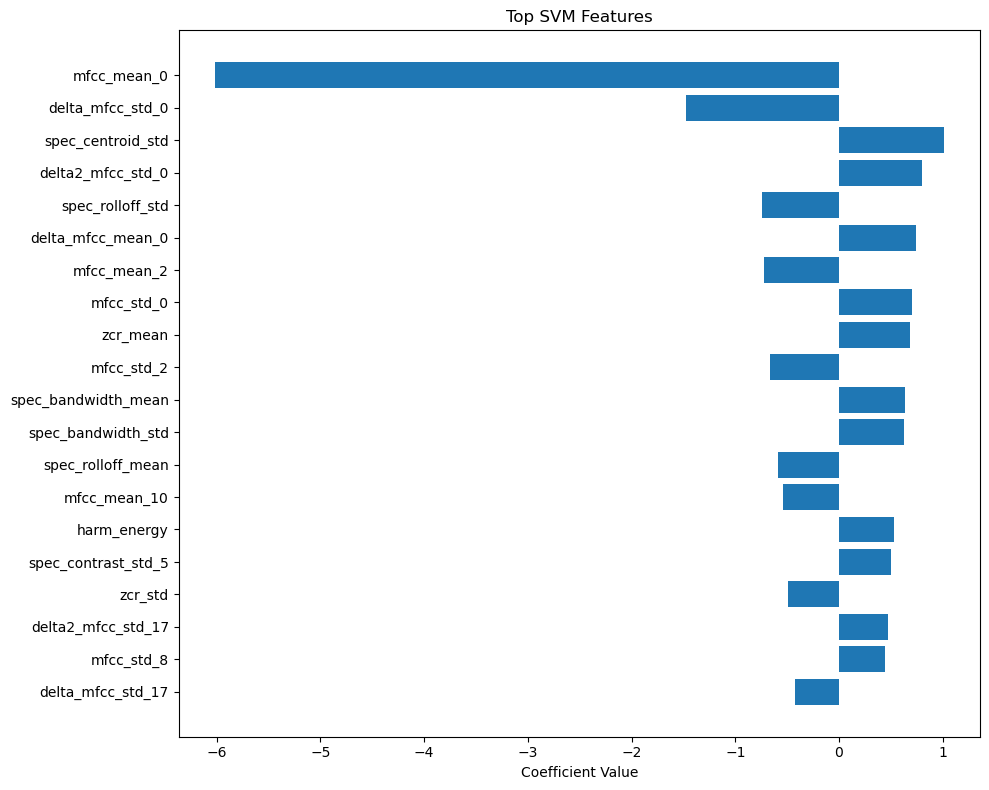

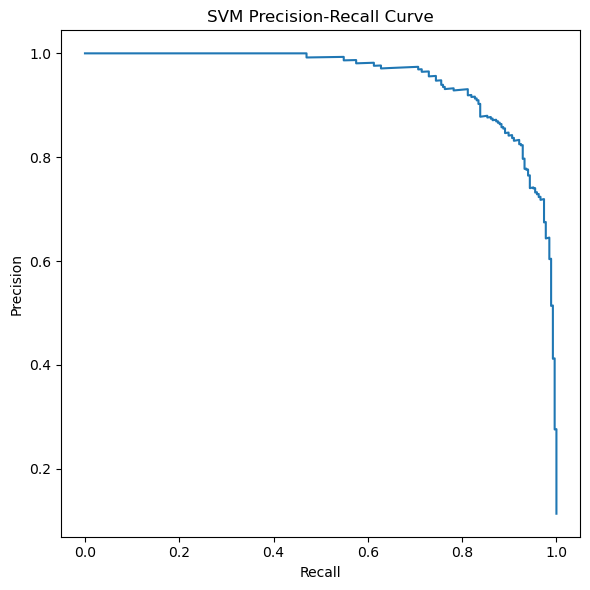

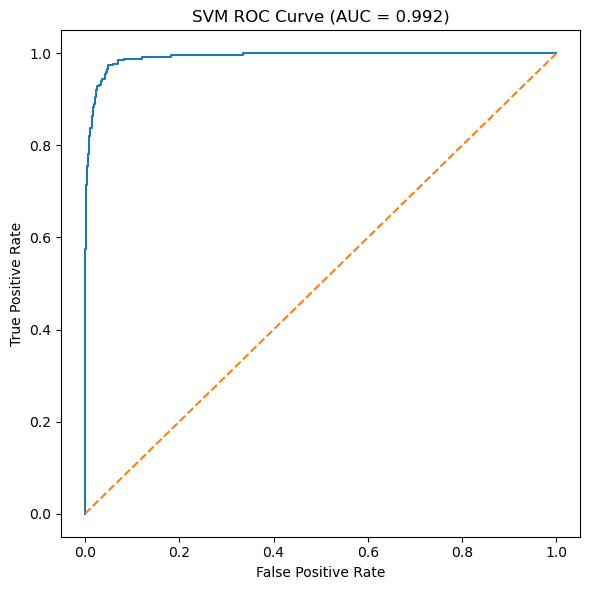

ROC AUC: 0.9917


In [25]:
#confusion matrix
cm = metrics["confusion_matrix"]
im = ConfusionMatrixDisplay(confusion_matrix=cm, 
                            display_labels=["drone", "unknown"])
im.plot()
plt.title("SVM Confusion Matrix")
plt.tight_layout()
plt.show()


#most impactful features
classifier = svm_model.named_steps["classifier"]
coeffs = classifier.coef_[0]

print("Num features:", len(feature_names))
print("Num coeffs:  ", len(coeffs))

importance = np.abs(coeffs)
top_n = 20
top_idx = np.argsort(importance)[-top_n:]
top_features = [feature_names[i] for i in top_idx]
top_values = coeffs[top_idx]
fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(top_features, top_values)
ax.set_title("Top SVM Features")
ax.set_xlabel("Coefficient Value")
plt.tight_layout()
plt.show()

#pr curve
precision, recall, _ = precision_recall_curve(drone_true, drone_scores)
fig, ax = plt.subplots(figsize=(6, 6))

ax.plot(recall, precision)
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("SVM Precision-Recall Curve")
plt.tight_layout()
plt.show()

#roc
fpr, tpr, _ = roc_curve(drone_true, drone_scores)

roc_auc_svm = auc(fpr, tpr)
fig, ax = plt.subplots(figsize=(6, 6))

ax.plot(fpr, tpr)
ax.plot([0, 1], [0, 1], linestyle="--")

ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title(f"SVM ROC Curve (AUC = {roc_auc_svm:.3f})")
plt.tight_layout()
plt.show()

print(f'ROC AUC: {roc_auc_svm:.4f}')

# Test on other files

## Load data

In [26]:
def load_ext_dataset(dir_test=DIR_TEST):
    X_ext = []
    filenames = []

    for filename in os.listdir(dir_test):
        if not filename.lower().endswith(".wav"):
            continue
        filepath = os.path.join(dir_test, filename)
        try:
            features = wav_to_data(filepath)
            X_ext.append(features)
            filenames.append(filename)
        except Exception as e:
            print(f"Skipping {filepath}: {e}")

    X_ext = np.stack(X_ext)

    return X_ext, filenames

In [27]:
start = time.perf_counter()
X_live, filenames = load_ext_dataset()
end = time.perf_counter()
liveTime = end-start

In [28]:
print(f'time taken: {svmTrainTime:.2f} s = {svmTrainTime*1e3:.1f} ms')

time taken: 0.16 s = 158.5 ms


In [29]:
X_live.shape

(3, 143)

3 files, 143 features each

In [30]:
filenames

['cow.wav', 'lawn_mower.wav', 'drone.wav']

In [31]:
from IPython.display import Audio, display

for file in filenames:
    print(file)
    audio = Audio(os.path.join(DIR_TEST, file))
    display(audio)

cow.wav


lawn_mower.wav


drone.wav


## Test on models

### Log reg

In [34]:
#log reg
start = time.perf_counter()
y_pred_log_live = log_model.predict(X_live)

y_probs_log_live = log_model.predict_proba(X_live)
#log_prob_live = model.predict_proba(x)[0][1]

#find good level for this
threshold = 0.75 #need to be 75% sure it is a drone

# class 0 = drone
y_pred_log_thresh_live = np.where(y_probs_log_live > threshold, 0, 1)
end = time.perf_counter()
logPredictLiveTime = end-start

In [35]:
print(f'time taken: {logPredictLiveTime:.4f} s = {logPredictLiveTime*1e3:.1f} ms')

time taken: 0.0035 s = 3.5 ms


### SVM

In [36]:
start = time.perf_counter()
#hard
#y_pred_live = svm_model.predict(X_live)

#soft
scores_live = svm_model.decision_function(X_live)

# drone = class 0
drone_scores_live = -scores_live

threshold = 0.513 #found in other nb
#threshold = 0.6

y_pred_svm_live = np.where(drone_scores_live > threshold, 0, 1)

end = time.perf_counter()
svmPredictTimeLive = end-start

In [37]:
print(f'time taken: {svmPredictTimeLive:.4f} s = {svmPredictTimeLive*1e3:.1f} ms')

time taken: 0.0006 s = 0.6 ms


## Results

In [38]:
def predToClass(result):
    classification = 'other'
    if result == 0:
        classification = 'Drone'
    return classification

In [39]:
print('0=drone, 1=other\n')

for i in range(len(X_live)):
    print(f'File: {filenames[i]}')
    #log pred
    #print(f'LogReg prediction: {y_pred_log_thresh_live[:][i]}')
    print(f'LogReg prediction: {y_pred_log_live[i]} = {predToClass(y_pred_log_live[i])}')
    #log prob
    print(f'LogReg probability of drone: {y_probs_log_live[i][0]*100:.4f}%')

    #svm pred
    print(f'SVM prediction: {y_pred_svm_live[i]} = {predToClass(y_pred_svm_live[i])}')
    #svm score
    print(f'SVM score: {scores_live[i]:.2f}')
    print('\n')


0=drone, 1=other

File: cow.wav
LogReg prediction: 1 = other
LogReg probability of drone: 0.0000%
SVM prediction: 1 = other
SVM score: 7.82


File: lawn_mower.wav
LogReg prediction: 1 = other
LogReg probability of drone: 18.2647%
SVM prediction: 1 = other
SVM score: 1.55


File: drone.wav
LogReg prediction: 0 = Drone
LogReg probability of drone: 97.2776%
SVM prediction: 0 = Drone
SVM score: -0.75




Yay! Live test works!